In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import AFT_tools as AFT

plt.style.use('../libs/my_style.mplstyle')

path="/Volumes/data/Sasaki/MTsingleBeads/20260122/exp001"

green = zarr.open_array(os.path.join(path, "MTs.zarr"), read_only=True)
red =  zarr.open_array(os.path.join(path, "MTs_red.zarr"), read_only=True)

In [8]:
# AFT parameters
window_size_um = 10 # MTs length = 10um
frame = 100

scale = 0.11  # um/pixel

#### required parameters ####
window_size = int(window_size_um/scale)
overlap = 0.8
neighborhood_radius = 1

d = 30

#crop, mask = crop_around_trajectory(traj_solo, MTs_smoothed, d, scale)

In [ ]:
x, y, u, v, im_theta, im_eccentricity = AFT.image_local_order(green[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

x_red, y_red, u_red, v_red, im_theta_red, im_eccentricity_red = AFT.image_local_order(red[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

[Text(0.5, 0, 't[s]'), Text(0, 0.5, 'Order parameter'), (0.0, 1.0)]

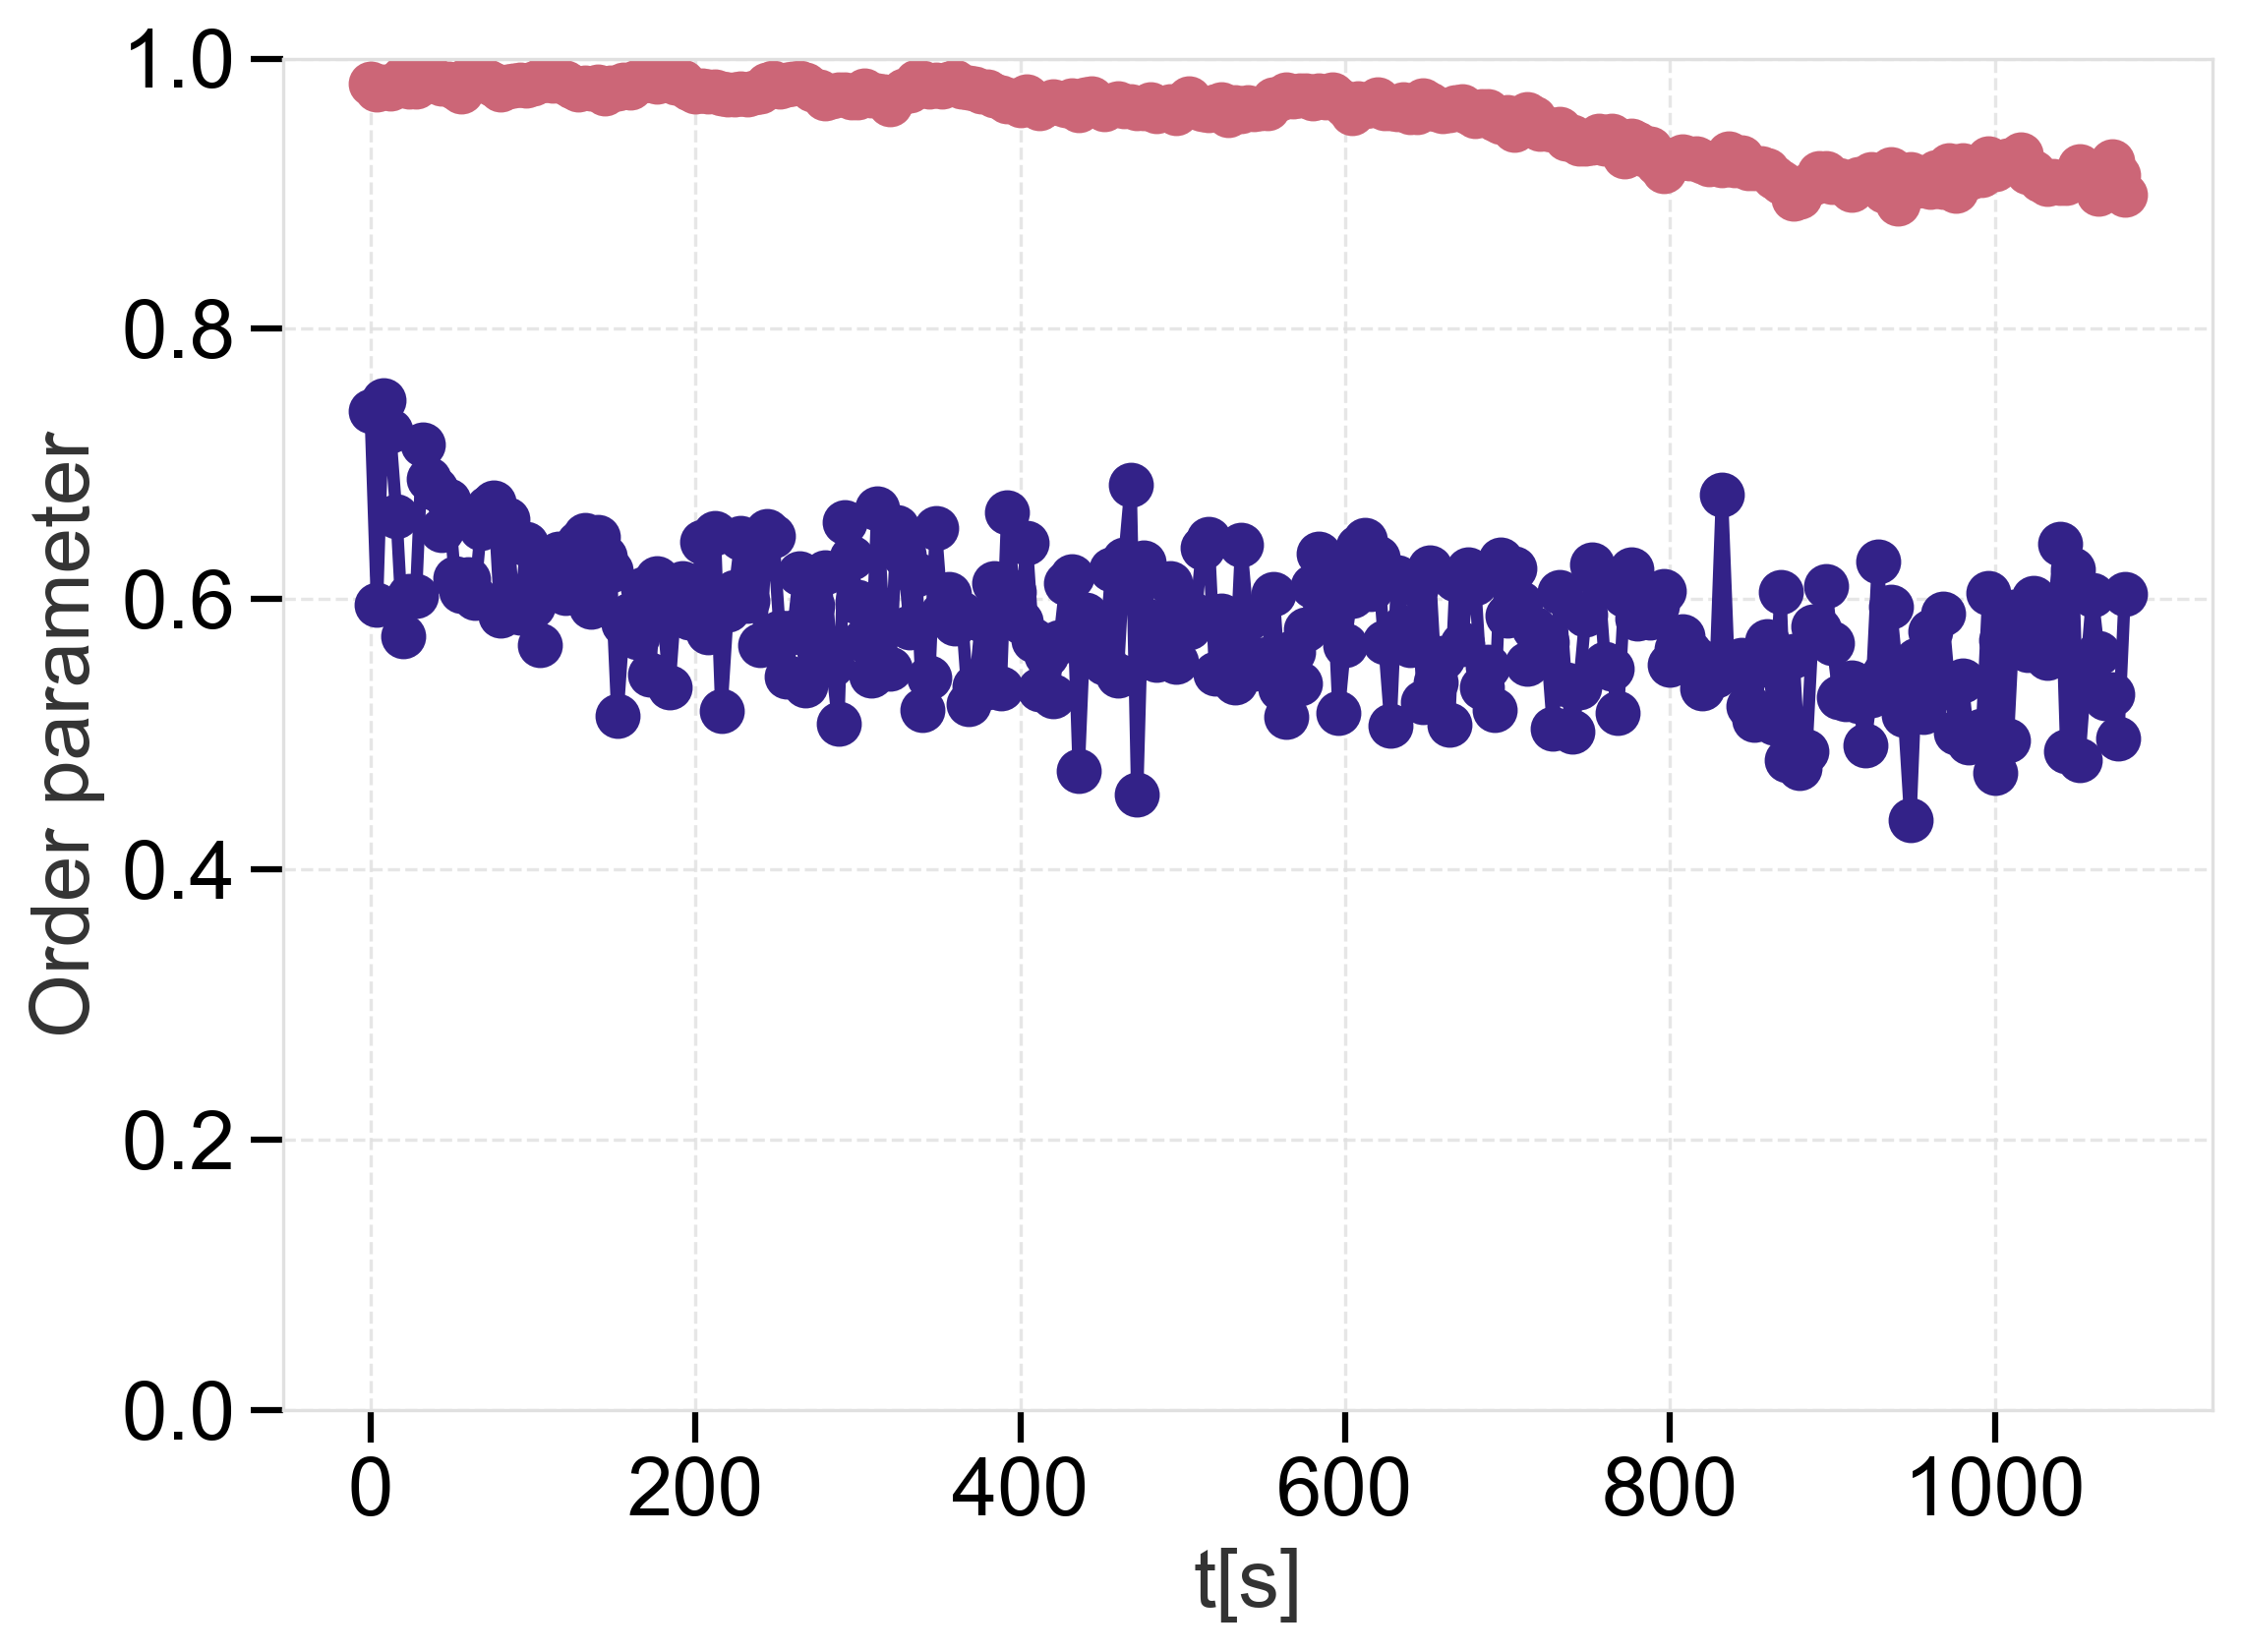

In [ ]:
interval = 4

im_order_parameter = AFT.calculate_order_parameter(im_theta, neighborhood_radius)
order_parameter = np.array([np.arange(0, interval*len(im_order_parameter), interval) ,im_order_parameter])

im_order_parameterR = AFT.calculate_order_parameter(im_theta_red, neighborhood_radius)
order_parameterR = np.array([np.arange(0, interval*len(im_order_parameterR), interval) ,im_order_parameterR])

fig, ax = plt.subplots()
ax.plot(order_parameter[0,:], order_parameter[1,:], marker='o', linestyle='-')
ax.plot(order_parameterR[0,:], order_parameterR[1,:], marker='o', linestyle='-')

ax.set(xlabel='t[s]',
       ylabel='Order parameter',
       ylim=(0, 1))

#print('The order parameter is {0}'.format(im_order_parameter))

In [ ]:
zarr.save(f"{path[:-9]}/order_parameter.zarr", order_parameter)
zarr.save(f"{path[:-9]}/order_parameterRed.zarr", order_parameterR)

In [6]:
"""means = []
for theta in im_theta:
    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))
    means.append(mean)
    
fig, ax = plt.subplots()
ax.plot(np.arange(len(means))*10, means, marker='o', linestyle='None')
ax.set(xlabel='t[s]',
       ylabel='Mean angle [rad]',
       ylim=(-np.pi/2, np.pi/2))

from scipy.optimize import curve_fit

def fit(x, a, b):
    return a * x + b
popt, pcov = curve_fit(fit, np.arange(len(means))*10, means)

ax.plot(np.arange(len(means))*10, fit(np.arange(len(means))*10, *popt), label = f'{popt[0]:.4f} t + {popt[1]:.4f}')
ax.legend()"""

"means = []\nfor theta in im_theta:\n    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))\n    means.append(mean)\n\nfig, ax = plt.subplots()\nax.plot(np.arange(len(means))*10, means, marker='o', linestyle='None')\nax.set(xlabel='t[s]',\n       ylabel='Mean angle [rad]',\n       ylim=(-np.pi/2, np.pi/2))\n\nfrom scipy.optimize import curve_fit\n\ndef fit(x, a, b):\n    return a * x + b\npopt, pcov = curve_fit(fit, np.arange(len(means))*10, means)\n\nax.plot(np.arange(len(means))*10, fit(np.arange(len(means))*10, *popt), label = f'{popt[0]:.4f} t + {popt[1]:.4f}')\nax.legend()"